# Projeto 2
#### Tema : Processo de estratégias de processamento de dados em larga escala.
**Tiago Riscado Nº 52935**

**Rodrigo Soares Nº 51589**

**Carlota Santos Nº51658**

Link do Github :  (repositório público)

#### **Contribuições**:
**Tiago Riscado** : 

**Rodrigo Soares** : 

**Carlota Santos** : 

#### **Motivação**

A Inteligência Artificial tem tido uma evolução notória e está cada vez mais presente no quotidiano da sociedade. Por este motivo, consideramos relevante analisar como este tema é abordado por diferentes meios de comunicação. 

Este projeto compara notícias de Inteligênca Artificial publicadas por várias fontes ao longo do tempo, com o principal objetivo de entender a evolução das notícias e identificar as possiveis difenrenças entre as fontes analisadas.

Foram recolhidas, tratadas e analisadas notícias relacionadas com IA, permitindo identificar padrões temporais e variações na quantidade de notícias publicadas por cada fonte e autor.

Como melhorias futuras, seria intressante aumentar o número de fontes e aplicar técnicas como análise de sentimento ou extração de tópicos.

### Declaração de Integridade

Eu, Tiago Riscado, Rodrigo Soares e Carlota Santos, estudantes com os números de inscrição 52935, 51589 e 51658 (respetivamente) de/o 1º Ciclo em Inteligência Artificial e Ciência de Dados (Tiago e Carlota) e de/o 1º Ciclo em Informática Web, Móvel e na Nuvem (Rodrigo) da Universidade da Beira Interior, declaramos ter desenvolvido o presente trabalho e elaborado o presente texto em total consonância com o Código de Integridade da Universidade da Beira Interior. Mais concretamente afirmamos não ter incorrido em qualquer das variedades de Fraude Académica, e que aqui declaramos conhecer, que em particular atendi à exigida referenciação de frases, extratos, imagens e outras formas de trabalho intelectual, e assumindo assim na íntegra as responsabilidades da autoria. 

Universidade da Beira Interior, Covilhã  
21/05/2026

### Declaração do uso de IA Generativa

Durante o desenvolvimento deste trabalho, os autores usaram as seguintes ferramentas:

**Ferramentas e Serviços:**
- Claude (Anthropic)
- Codex

**Contribuição das ferramentas:**


## Questão 1 - Leitura do chunk, tipos de dados e substituição de -9999 por NaN

O dataset GHCN-Daily contém registos meteorológicos diários de milhares de estações em todo o mundo. Cada linha representa um mês de observações numa estação, com os valores diários nas colunas `value1` a `value31`. O valor `-9999` é usado como código de dado em falta e é convertido para `NaN` na leitura.

Como o ficheiro ocupa cerca de 12 GB em RAM sem otimização, utilizámos `chunksize` para o processar em blocos de 500 000 linhas, e `usecols` para carregar apenas as 35 colunas relevantes. Os tipos de dados foram também ajustados reduzindo significativamente o consumo de memória:
- `int16` para o ano
- `int8` para o mês 
- `float32` para os valores diários

In [1]:
import pandas as pd 
import numpy as np 
from dotenv import load_dotenv
import os
import psutil
load_dotenv(override=True)

DATA_PATH = os.getenv('CSV_PATH')
STATIONS_PATH = os.getenv('STATIONS_PATH')


In [6]:
VALUE_COLS = [f'value{i}' for i in range(1, 32)]
USE_COLS = ['id', 'year', 'month', 'element'] + VALUE_COLS

DTYPES = {
    'id': 'string',
    'year': 'int16',
    'month': 'int8',
    'element': 'string',
}
for col in VALUE_COLS:
    DTYPES[col] = 'float32'

CHUNK_SIZE = 500_000

df = pd.read_csv(DATA_PATH, usecols=USE_COLS, dtype=DTYPES, na_values=[-9999], chunksize=CHUNK_SIZE)

chunk = next(df)

print(f"Formato do chunk: {chunk.shape}")
print(f"Tipos de dados do chunk:\n{chunk.dtypes}")
print(f"Primeiras 5 linhas do chunk:\n{chunk.head()}")


Formato do chunk: (500000, 35)
Tipos de dados do chunk:
id          string
year         int16
month         int8
element     string
value1     float32
value2     float32
value3     float32
value4     float32
value5     float32
value6     float32
value7     float32
value8     float32
value9     float32
value10    float32
value11    float32
value12    float32
value13    float32
value14    float32
value15    float32
value16    float32
value17    float32
value18    float32
value19    float32
value20    float32
value21    float32
value22    float32
value23    float32
value24    float32
value25    float32
value26    float32
value27    float32
value28    float32
value29    float32
value30    float32
value31    float32
dtype: object
Primeiras 5 linhas do chunk:
            id  year  month element  value1  value2  value3  value4  value5  \
0  ACW00011604  1949      1    TMAX   289.0   289.0   283.0   283.0   289.0   
1  ACW00011604  1949      2    TMAX   267.0   278.0   272.0   267.0   278.0   

### Questão 2 — Percentagem de valores nulos por coluna

Calculámos a percentagem de valores nulos em cada variável do chunk lido. As colunas `value1` a `value31` apresentam taxas de nulos variáveis, uma vez que nem todos os meses têm 31 dias, por exemplo, `value31` é nulo em todos os meses com menos de 31 dias. As colunas de identificação (`id`, `year`, `month`, `element`) não têm valores nulos.

In [4]:
null_count = (chunk.isnull().sum() / len(chunk) * 100).round(2)
null_df = null_count.reset_index()
null_df.columns = ['coluna', 'percentagem_nulos (%)']

print("Percentagem de valores nulos por coluna:")
null_df


Percentagem de valores nulos por coluna:


,coluna,percentagem_nulos (%)
0,id,0.00
1,year,0.00
2,month,0.00
3,element,0.00
4,value1,9.96
5,value2,10.00
6,value3,9.95
7,value4,10.08
8,value5,9.94
9,value6,9.95


### Questão 3 — Ano mais antigo e mais recente por estação

Para determinar o intervalo temporal de cada estação meteorológica, processámos o ficheiro completo em chunks, acumulando o mínimo e o máximo do ano para cada `id`. Este processo evita carregar todo o dataset para memória, sendo adequado para ficheiros de grande dimensão.

In [50]:
chunk_results = []

reader = pd.read_csv(
    DATA_PATH,
    usecols=['id', 'year'],
    dtype={'id': 'string', 'year': 'int16'},
    chunksize=CHUNK_SIZE
)

for ck in reader:
    grp = ck.groupby('id')['year'].agg(['min', 'max'])
    chunk_results.append(grp)

anos = pd.concat(chunk_results).groupby('id').agg({'min': 'min', 'max': 'max'})

anos.columns = ['ano_mais_antigo', 'ano_mais_recente']
anos = anos.reset_index()

print(f"Total de estações: {len(anos)}")
anos.head(10)

Total de estações: 40133


,id,ano_mais_antigo,ano_mais_recente
0,ACW00011604,1949,1949
1,ACW00011647,1961,1961
2,AE000041196,1944,2019
3,AEM00041194,1983,2019
4,AEM00041217,1983,2019
5,AEM00041218,1994,2019
6,AF000040930,1973,1992
7,AFM00040938,1973,2019
8,AFM00040948,1966,2019
9,AFM00040990,1973,2019


### Questão 4 — Temperatura média diária por observação

Para cada linha do dataset (que representa um mês numa estação), calculámos a média dos valores diários das colunas `value1` a `value31`, ignorando os `NaN`, apos o calculo os resultados foram guardados numa nova coluna `daily_avg_temp`.

In [9]:
# Calcular média ignorando NaN apenas sobre as colunas value1..value31
chunk['daily_avg_temp'] = chunk[VALUE_COLS].mean(axis=1)

print("Primeiras linhas com daily_avg_temp:")
chunk[['id', 'year', 'month', 'element', 'daily_avg_temp']].head(10)


Primeiras linhas com daily_avg_temp:


,id,year,month,element,daily_avg_temp
0,ACW00011604,1949,1,TMAX,274.612915
1,ACW00011604,1949,2,TMAX,271.142853
2,ACW00011604,1949,3,TMAX,277.935486
3,ACW00011604,1949,4,TMAX,287.166656
4,ACW00011604,1949,5,TMAX,291.354828
5,ACW00011604,1949,6,TMAX,294.833344
6,ACW00011604,1949,7,TMAX,298.709686
7,ACW00011647,1961,10,TMAX,272.000000
8,AE000041196,1944,3,TMAX,323.166656
9,AE000041196,1944,4,TMAX,321.466675


### Questão 5 — Agregar por estação e ano

Agrupámos os dados por estação (`id`) e por ano, calculando a média da coluna `daily_avg_temp`. Isto permitiu observar a evolução da temperatura média anual em cada estação ao longo dos anos.

In [10]:
temp_by_station_year = (
    chunk
    .groupby(['id', 'year'])['daily_avg_temp']
    .mean()
    .round(2)
    .reset_index()
)

print("Temperatura média anual por estação:")
temp_by_station_year.head(15)


Temperatura média anual por estação:


,id,year,daily_avg_temp
0,ACW00011604,1949,285.109985
1,ACW00011647,1961,272.000000
2,AE000041196,1944,348.869995
3,AE000041196,1945,318.230011
4,AE000041196,1955,317.920013
5,AE000041196,1956,318.109985
6,AE000041196,1957,311.390015
7,AE000041196,1958,317.899994
8,AE000041196,1959,309.899994
9,AE000041196,1960,316.929993


### Questão 6 — Selecionar as 5 estações meteorológicas portuguesas

Para filtrar as estações portuguesas, começámos por ler o ficheiro auxiliar `ghcnd-stations.txt`, que contém informação sobre todas as estações meteorológicas do dataset incluindo o seu ID, coordenadas geográficas e nome.

De seguida, filtraram-se as 5 estações portuguesas presentes no dataset: **Horta, Funchal, Lisboa, Castelo Branco e Faro**, obtendo os respetivos IDs. Por fim, percorreu-se o dataset completo em chunks, guardando apenas os registos cujo `id` corresponde a uma dessas estações, e concatenaram-se os resultados num único DataFrame `df_pt`.

In [35]:
stations = pd.read_fwf(
    STATIONS_PATH,
    colspecs=[(0, 11), (12, 20), (21, 30), (31, 37), (38, 40), (41, 71)],
    names=['id', 'lat', 'lon', 'elev', 'state', 'name'],
    dtype={'id': 'string', 'name': 'string'}
)
stations['name'] = stations['name'].str.strip()

PT_NAMES = ['HORTA (AZORES)', 'FUNCHAL', 'LISBOA GEOFISICA', 'CASTELO BRANCO', 'FARO']
pt_stations = stations[stations['name'].str.upper().isin(PT_NAMES)]
PT_IDS = pt_stations['id'].tolist()

print("Estações portuguesas encontradas:")
print(pt_stations[['id', 'name']])

# Filtrar o dataset completo
pt_chunks = []
for ck in pd.read_csv(DATA_PATH, usecols=USE_COLS, dtype=DTYPES, na_values=[-9999], chunksize=CHUNK_SIZE):
    pt_chunks.append(ck[ck['id'].isin(PT_IDS)])

df_pt = pd.concat(pt_chunks, ignore_index=True)
print(f"\nRegistos das estações portuguesas: {df_pt.shape}")
df_pt.head()

Estações portuguesas encontradas:
                id              name
25404  CA002100515              FARO
25405  CA002100516              FARO
47044  PO000008506    HORTA (AZORES)
47045  PO000008522           FUNCHAL
47046  PO000008535  LISBOA GEOFISICA
47065  POM00008554              FARO
47067  POM00008570    CASTELO BRANCO
50472  SWE00138286              FARO

Registos das estações portuguesas: (3268, 35)


,id,year,month,element,value1,value2,value3,value4,value5,value6,...,value22,value23,value24,value25,value26,value27,value28,value29,value30,value31
0,CA002100515,1966,4,TMAX,11.0,50.0,67.0,61.0,56.0,61.0,...,-17.0,-22.0,6.0,-6.0,-17.0,28.0,44.0,28.0,50.0,NaN
1,CA002100515,1966,5,TMAX,67.0,67.0,56.0,61.0,83.0,156.0,...,50.0,50.0,72.0,72.0,72.0,56.0,67.0,89.0,122.0,139.0
2,CA002100515,1966,6,TMAX,128.0,167.0,172.0,139.0,156.0,183.0,...,183.0,178.0,222.0,195.0,178.0,100.0,156.0,156.0,172.0,NaN
3,CA002100515,1966,7,TMAX,206.0,178.0,150.0,167.0,228.0,222.0,...,NaN,NaN,217.0,200.0,189.0,167.0,117.0,122.0,117.0,161.0
4,CA002100515,1966,8,TMAX,128.0,122.0,167.0,172.0,217.0,234.0,...,133.0,150.0,139.0,133.0,128.0,161.0,167.0,139.0,122.0,117.0


### Questão 7 — Substituir IDs pelo nome da estação

Para tornar o dataframe mais legível, substituímos os IDs das estações pelo respetivo nome. Para isso, criámos um dicionário de mapeamento `id → nome` a partir do ficheiro de estações, e aplicámos esse mapeamento à coluna `id` com o método `.map()`. Por fim, renomeámos a coluna de `id` para `station_name`.

In [16]:
# Criar mapeamento id -> nome
id_to_name = dict(zip(pt_stations['id'], pt_stations['name']))

df_pt['id'] = df_pt['id'].map(id_to_name)
df_pt = df_pt.rename(columns={'id': 'station_name'})

print("Estações únicas no dataframe:")
print(df_pt['station_name'].unique())
print()
df_pt[['station_name', 'year', 'month', 'element']].head(10)

Estações únicas no dataframe:
<ArrowStringArray>
['FARO', 'FUNCHAL', 'CASTELO BRANCO']
Length: 3, dtype: str



,station_name,year,month,element
0,FARO,1966,4,TMAX
1,FARO,1966,5,TMAX
2,FARO,1966,6,TMAX
3,FARO,1966,7,TMAX
4,FARO,1966,8,TMAX
5,FARO,1966,9,TMAX
6,FARO,1966,10,TMAX
7,FARO,1966,11,TMAX
8,FARO,1966,12,TMAX
9,FARO,1967,1,TMAX


In [17]:
print(df_pt.columns.tolist())
print(df_pt.head(2))

['station_name', 'year', 'month', 'element', 'value1', 'value2', 'value3', 'value4', 'value5', 'value6', 'value7', 'value8', 'value9', 'value10', 'value11', 'value12', 'value13', 'value14', 'value15', 'value16', 'value17', 'value18', 'value19', 'value20', 'value21', 'value22', 'value23', 'value24', 'value25', 'value26', 'value27', 'value28', 'value29', 'value30', 'value31']
  station_name  year  month element  value1  value2  value3  value4  value5  \
0         FARO  1966      4    TMAX    11.0    50.0    67.0    61.0    56.0   
1         FARO  1966      5    TMAX    67.0    67.0    56.0    61.0    83.0   

   value6  ...  value22  value23  value24  value25  value26  value27  value28  \
0    61.0  ...    -17.0    -22.0      6.0     -6.0    -17.0     28.0     44.0   
1   156.0  ...     50.0     50.0     72.0     72.0     72.0     56.0     67.0   

   value29  value30  value31  
0     28.0     50.0      NaN  
1     89.0    122.0    139.0  

[2 rows x 35 columns]


## Exercicio 2

### Questão 1 — Escolha e caracterização do dataset

**Dataset escolhido:** NYC Yellow Taxi Trip Records, foi efetuado um merge dos CSVs de janeiro e fevereiro de 2026 para que o conjuto cumprisse os requesitos de enunciado.

**Fonte:** NYC Taxi & Limousine Commission (TLC)  
**Disponível em:** https://www.kaggle.com/datasets/elemento/nyc-yellow-taxi-trip-data

**Descrição:**  
O dataset contém registos de viagens de táxis amarelos na cidade de Nova Iorque, recolhidos e disponibilizados publicamente pela NYC Taxi & Limousine Commission. Cada linha representa uma viagem individual e inclui informação sobre o momento de início e fim da viagem, número de passageiros, distância percorrida, localização de recolha e entrega (coordenadas GPS), tipo de pagamento e valores monetários.
| Campo | Descrição |
|---|---|
| `tpep_pickup_datetime` | Data e hora de início da viagem |
| `tpep_dropoff_datetime` | Data e hora de fim da viagem |
| `passenger_count` | Número de passageiros |
| `trip_distance` | Distância percorrida (milhas) |
| `pickup_longitude/latitude` | Coordenadas GPS de recolha |
| `dropoff_longitude/latitude` | Coordenadas GPS de entrega |
| `payment_type` | Tipo de pagamento (1=cartão, 2=dinheiro, ...) |
| `fare_amount` | Tarifa base |
| `tip_amount` | Gorjeta |
| `total_amount` | Valor total pago |

**Porque é adequado para um exercício de processamento de dados em larga escala?**  
Este dataset justifica uma abordagem cuidadosa por várias razões. Em primeiro lugar, os 3.29 GB em disco expandem para 8 a 10 GB em RAM quando carregados com os tipos padrão do pandas (`float64`, `object`), o que em computadores mais limitados torna-se inviável uma leitura direta. Em segundo lugar, as 22 milhões de linhas obrigam a pensar na eficiência das operações como o `groupby`.  Por fim, a diversidade de tipos de variáveis (datas, coordenadas, inteiros, floats, categóricas) permite demonstrar várias técnicas de otimização de memória.

In [23]:
taxi_csv = os.getenv('TAXI_PATH') 

# Tamanho em disco
print(f"Tamanho do ficheiro: {os.path.getsize(taxi_csv) / 1024**3:.2f} GB")

# Contar linhas sem carregar tudo para memória
with open(taxi_csv, 'r') as f:
    n_lines = sum(1 for _ in f) - 1  # -1 para o cabeçalho

print(f"Total de linhas: {n_lines:,}")


Tamanho do ficheiro: 3.29 GB
Total de linhas: 22,288,907


### Q2 — Estratégia de leitura dos dados

**Caracterização do dataset:**
- Tamanho em disco: 3.29 GB
- Total de linhas: ~22 milhões
- Resultado da junção de 4 ficheiros mensais (Jan/2015, Jan/2016, Fev/2016, Mar/2016)

**O dataset cabe em memória?**  
Com 32 GB de RAM disponíveis, o ficheiro de 3.29 GB em disco cabe em memória na máquina utilizada para desenvolvimento. No entanto, nem todos os membros do grupo dispõem desta quantidade de RAM logo carregar o ficheiro diretamente sem otimização seria inviável, uma vez que um CSV de 3.29 GB pode expandir para 8–10 GB em RAM. Por isso, a estratégia adotada foi desenhada para funcionar em qualquer máquina para isto foi utilizado:
- `usecols` — carregar apenas as colunas necessárias para a análise
- `dtype` — forçar tipos mais pequenos (`float32`, `int8`, `category`)
- `chunksize` — processar em chunks de 500k linhas para operações pesadas

**Que colunas são realmente necessárias?**  
Das 19 colunas disponíveis, selecionamos apenas 10 relevantes para a análise:
tpep_pickup_datetime, tpep_dropoff_datetime, passenger_count, trip_distance,
payment_type, fare_amount, tip_amount, total_amount, pickup_longitude, pickup_latitude

**Que tipos de dados podem ser otimizados?**  
- Valores monetários e distância: float64 → float32 (50% menos memória)
- passenger_count: int64 → int8 (valores 0–6)
- payment_type: int64 → category (só 5 valores distintos)

**É necessário processar por partes?**  
Para operações simples (leitura, filtros, criação de variáveis) não é necessário. 
Para agregações globais sobre as 22M linhas usamos chunksize para evitar picos de memória.

### Q3 — Leitura de uma amostra ou chunk

O ficheiro `yellow_taxi_merged.csv` possui um tamanho de 3,29GB com cerca de 22 milhões de linhas. Por isso, é utilizado o `chunksize=500_000` para que não seja preciso carregar todo o ficheiro na memória simultaneamente. O chunk inicial serve para validar a configuração das colunas, tipos de dados e valores nulos.

In [45]:
TAXI_CHUNK_SIZE = 500_000

TAXI_READER = pd.read_csv(taxi_csv, chunksize=TAXI_CHUNK_SIZE)
taxi_chunk = next(TAXI_READER)
first_5_lines = taxi_chunk.head()

print(f"\nPrimeiras 5 linhas do chunk:{first_5_lines}")

print(f"Número de linhas e colunas: {taxi_chunk.shape}")
print(f"\nNomes das colunas:\n{taxi_chunk.columns.tolist()}")




Primeiras 5 linhas do chunk:   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         2  2016-01-01 00:00:00   2016-01-01 00:00:00                2   
1         2  2016-01-01 00:00:00   2016-01-01 00:00:00                5   
2         2  2016-01-01 00:00:00   2016-01-01 00:00:00                1   
3         2  2016-01-01 00:00:00   2016-01-01 00:00:00                1   
4         2  2016-01-01 00:00:00   2016-01-01 00:00:00                3   

   trip_distance  pickup_longitude  pickup_latitude  RatecodeID  \
0           1.10        -73.990372        40.734695           1   
1           4.90        -73.980782        40.729912           1   
2          10.54        -73.984550        40.679565           1   
3           4.75        -73.993469        40.718990           1   
4           1.76        -73.960625        40.781330           1   

  store_and_fwd_flag  dropoff_longitude  dropoff_latitude  payment_type  \
0                  N         -73.981842   

**Descrição das variáveis principais:**
- `tpep_pickup_datetime` / `tpep_dropoff_datetime` - horário e data de incio e fim do trajeto
- `passenger_count` - quantidade de passageiros
- `trip_distance` - distância percorrida(milhas)
- `payment_type` - forma de pagamento (1 - cartão, 2 - dinheiro, 3 - sem cobrança, 4 - disputa)
- `fare_amount` - tarifa básica do trajeto
- `tip_amount` - gorjeta paga
- `total_amount` - valor total cobrado ao passageiro

#### Q4 - Otimização dos tipos de dados

##### **1. Análise do tipo de dados e memória antes da otimização**
Antes da otimização, analisámos os tipos de dados definidos pelo pandas e a memória usada pelo chunk, para servir de comparação

In [25]:
print("Tipos de dados:")
print(taxi_chunk.dtypes)
print(f"\nMemória total: {taxi_chunk.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Tipos de dados:
VendorID                   int64
tpep_pickup_datetime         str
tpep_dropoff_datetime        str
passenger_count            int64
trip_distance            float64
pickup_longitude         float64
pickup_latitude          float64
RatecodeID                 int64
store_and_fwd_flag           str
dropoff_longitude        float64
dropoff_latitude         float64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
dtype: object

Memória total: 91.08 MB


##### **2. Aplicar otimizações e comparar memória**
De acordo com o resultado  da análise, conseguimos detetar as colunas que requerem mudança do tipo de dado. Transformamos as colunas com datas do tipo texto para `datetime64`, as colunas com inteiros com um número pequeno de categorias para `int8`, a coluna com somente dois valores para `category` e todas as colunas `float` para `float32`.

In [26]:
taxi_otimizado = taxi_chunk.copy()

taxi_otimizado['tpep_pickup_datetime']  = pd.to_datetime(taxi_otimizado['tpep_pickup_datetime'])
taxi_otimizado['tpep_dropoff_datetime'] = pd.to_datetime(taxi_otimizado['tpep_dropoff_datetime'])

taxi_otimizado['VendorID']           = taxi_otimizado['VendorID'].astype('int8')
taxi_otimizado['passenger_count']    = taxi_otimizado['passenger_count'].astype('int8')
taxi_otimizado['RatecodeID']         = taxi_otimizado['RatecodeID'].astype('int8')
taxi_otimizado['payment_type']       = taxi_otimizado['payment_type'].astype('int8')
taxi_otimizado['store_and_fwd_flag'] = taxi_otimizado['store_and_fwd_flag'].astype('category')

colunas_float = ['trip_distance', 'pickup_longitude', 'pickup_latitude',
                 'dropoff_longitude', 'dropoff_latitude', 'fare_amount',
                 'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
                 'improvement_surcharge', 'total_amount']

taxi_otimizado[colunas_float] = taxi_otimizado[colunas_float].astype('float32')

mem_antes = taxi_chunk.memory_usage(deep=True).sum() / 1024**2
mem_depois = taxi_otimizado.memory_usage(deep=True).sum() / 1024**2

print(f"Memória antes:  {mem_antes:.2f} MB")
print(f"Memória depois: {mem_depois:.2f} MB")
print(f"Redução:        {(1 - mem_depois / mem_antes) * 100:.1f}%")
print("\nNovos tipos:")
print(taxi_otimizado.dtypes)


Memória antes:  91.08 MB
Memória depois: 32.90 MB
Redução:        63.9%

Novos tipos:
VendorID                           int8
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                    int8
trip_distance                   float32
pickup_longitude                float32
pickup_latitude                 float32
RatecodeID                         int8
store_and_fwd_flag             category
dropoff_longitude               float32
dropoff_latitude                float32
payment_type                       int8
fare_amount                     float32
extra                           float32
mta_tax                         float32
tip_amount                      float32
tolls_amount                    float32
improvement_surcharge           float32
total_amount                    float32
dtype: object


**Resumo das otimizações realizadas:**

| Coluna| Antes | Depois | Porquê? |
|---|---|---|---|
|`tpep_pickup_datetime`, `tpep_dropoff_datetime` | `str` | `datetime64` | As datas guardadas como texto. Ao convertê-las para formato de data, o uso de memória fica mais eficiente. |
| `VendorID`, `passenger_count`, `RatecodeID`, `payment_type` | `int64` | `int8` | Estas colunas têm valores pequenos, por isso não precisam de ocupar tanto espaço de memória.
| `store_and_fwd_flag` | `str` | `category` | Esta coluna só tem dois valores possiveis, `"Y"` e `"N"`, por isso o tipo `category` é mais adequado.
| 12 colunas numéricas, como `fare_amount`, coordenadas, etc..| `float` | `float32` | A precisão continua a ser suficiente e o consumo de memória passa a ser menor.

Depois destas alterações, a memória usada pelo chunk passou de **91.08** para **32.90 MB**, o que representa uma redução de cerca de **63.9%**

##### **3. Aplicar ao dataset completo**
Depois de validar as otimizações no chunk, implementamos as mesmas para a leitura do dataset completo, através do parâmetro `dtype` do `read_csv`. Assim, o pandas já carrega os dados com os tipos corretos desde o inicio, evitando um pico de memória caso a conversão fosse feita só depois da leitura.

In [27]:
TAXI_DTYPES = {
    'VendorID': 'int8',
    'passenger_count': 'int8',
    'RatecodeID': 'int8',
    'payment_type': 'int8',
    'store_and_fwd_flag': 'category',
    'trip_distance': 'float32',
    'pickup_longitude': 'float32',
    'pickup_latitude': 'float32',
    'dropoff_longitude': 'float32',
    'dropoff_latitude': 'float32',
    'fare_amount': 'float32',
    'extra': 'float32',
    'mta_tax': 'float32',
    'tip_amount': 'float32',
    'tolls_amount': 'float32',
    'improvement_surcharge': 'float32',
    'total_amount': 'float32',
}

df_taxi = pd.read_csv(
    taxi_csv,
    dtype=TAXI_DTYPES,
    parse_dates=['tpep_pickup_datetime', 'tpep_dropoff_datetime']
)

print(f"Shape: {df_taxi.shape}")
print(f"Memória total: {df_taxi.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Shape: (22288907, 19)
Memória total: 1466.69 MB


### Q5 - Valores em falta

#####  **1. Calcular a percentagem de NaN por coluna**
Iniciamos pela identificação da presença de dados nulos (NaN) na tabela completa. Isto é importante para conseguirmos perceber a dimensão inicial do problema da falta de dados.

In [28]:
null_pct = (df_taxi.isnull().sum() / len(df_taxi) * 100).round(2)
null_df = null_pct.reset_index()
null_df.columns = ['coluna', 'pct_nulos (%)']
print("Percentagem de valores nulos por coluna:")
null_df


Percentagem de valores nulos por coluna:


,coluna,pct_nulos (%)
0,VendorID,0.0
1,tpep_pickup_datetime,0.0
2,tpep_dropoff_datetime,0.0
3,passenger_count,0.0
4,trip_distance,0.0
5,pickup_longitude,0.0
6,pickup_latitude,0.0
7,RatecodeID,0.0
8,store_and_fwd_flag,0.0
9,dropoff_longitude,0.0


##### **2.  identificação de códigos especiais de missing values, se existirem.**
Embora não haja NaNs explicitos no conjunto de dados, é possível que existam valores usados como códigos de dados em falta, ou seja, valores numéricos que são válidos, mas que não têm significado real.

Por isso, analisámos alguns casos comuns neste tipo de dataset : viagens sem passageiro, distância igual a zero, coordenadas com valor zero e tarifas negativas ou nulas.

In [29]:
n = len(df_taxi)

print(f"passenger_count = 0:        {(df_taxi['passenger_count'] == 0).sum():,} ({(df_taxi['passenger_count'] == 0).sum()/n*100:.2f}%)")
print(f"trip_distance = 0:          {(df_taxi['trip_distance'] == 0).sum():,} ({(df_taxi['trip_distance'] == 0).sum()/n*100:.2f}%)")
print(f"pickup_longitude = 0:       {(df_taxi['pickup_longitude'] == 0).sum():,} ({(df_taxi['pickup_longitude'] == 0).sum()/n*100:.2f}%)")
print(f"pickup_latitude = 0:        {(df_taxi['pickup_latitude'] == 0).sum():,} ({(df_taxi['pickup_latitude'] == 0).sum()/n*100:.2f}%)")
print(f"fare_amount <= 0:           {(df_taxi['fare_amount'] <= 0).sum():,} ({(df_taxi['fare_amount'] <= 0).sum()/n*100:.2f}%)")
print(f"total_amount <= 0:          {(df_taxi['total_amount'] <= 0).sum():,} ({(df_taxi['total_amount'] <= 0).sum()/n*100:.2f}%)")


passenger_count = 0:        1,041 (0.00%)
trip_distance = 0:          131,749 (0.59%)
pickup_longitude = 0:       347,046 (1.56%)
pickup_latitude = 0:        347,046 (1.56%)
fare_amount <= 0:           15,016 (0.07%)
total_amount <= 0:          10,387 (0.05%)


##### **3. decisão sobre o tratamento dos valores em falta**
Com base nos valores encontrados, testámos duas formas de tratamento : remover esses registos ou substituir os valores pela mediana. O objetivo foi perceber qual das opções fazia mais sentido para este dataset.

In [30]:
df_taxi_clean = df_taxi[
    (df_taxi['passenger_count'] > 0) &
    (df_taxi['trip_distance'] > 0) &
    (df_taxi['pickup_longitude'] != 0) &
    (df_taxi['pickup_latitude'] != 0) &
    (df_taxi['fare_amount'] > 0) &
    (df_taxi['total_amount'] > 0)
].copy()

print(f"Linhas antes:     {len(df_taxi):,}")
print(f"Linhas depois:    {len(df_taxi_clean):,}")
print(f"Linhas removidas: {len(df_taxi) - len(df_taxi_clean):,} ({(1 - len(df_taxi_clean)/len(df_taxi))*100:.2f}%)")


Linhas antes:     22,288,907
Linhas depois:    21,822,582
Linhas removidas: 466,325 (2.09%)


Foram testadas duas formas de tratar os valores problemáticos encontrados:
| | Remoção | Substituição pela mediana |
| --- | --- | --- |
| Linhas mantidas | 21,822,582 | 22,288,907 |
| Perda de dados | 2.09% | 0% |
| Coordenadas inválidas | Removidas | Substituídas pela mediana de NYC|
| Tarifas < 0 | Removidas | Substituídas pela mediana |

**Decisão : Remoção**
A opção escolhida foi remover as linhas com valores inválidos. As coordenadas `(0,0)` não fazem sentido num dataset de taxis de Nova Iorque e substituí-las pela mediana poderia criar localizações artificias. O registo mesmo acontece com viagens de distância zero ou com tarifas negativas, que parecem ser erros de registo e não acrescentam valor à análise.

Como a remoção afeta apenas **2.09%** de mais de **22 milhões de linhas**, a perda de dados é reduzida e não compromete a representatividadr do datest. Assim, o dataframe final, `df_taxi_clean`, fica apenas com registos considerados válidos.

### Q6 - Criação de novas variáveis

A partir do dataframe limpo (`df_taxi_clean`) foram criadas novas variáveis para enriquecer a análise: duração da viagem, velocidade média, percentagem de gorjeta, mês/hora da recolha e identificação de pagamentos por cartão.


In [ ]:
# Usamos o dataframe limpo produzido na Q5.
df_taxi_analysis = df_taxi_clean.copy()

pickup = pd.to_datetime(df_taxi_analysis['tpep_pickup_datetime'], errors='coerce')
dropoff = pd.to_datetime(df_taxi_analysis['tpep_dropoff_datetime'], errors='coerce')

# Calcular duração da viagem em minutos
df_taxi_analysis['trip_duration_min'] = (
    (dropoff - pickup).dt.total_seconds() / 60
)

# Filtrar durações entre 1 minuto e 24 horas (1440 minutos)
df_taxi_analysis['trip_duration_min'] = df_taxi_analysis['trip_duration_min'].where(
    df_taxi_analysis['trip_duration_min'].between(1, 24 * 60)
)

# Calcular velocidade média em mph
df_taxi_analysis['avg_speed_mph'] = (
    df_taxi_analysis['trip_distance'] / (df_taxi_analysis['trip_duration_min'] / 60)
)

# Filtrar velocidades entre 1 mph e 100 mph
df_taxi_analysis['avg_speed_mph'] = df_taxi_analysis['avg_speed_mph'].where(
    df_taxi_analysis['avg_speed_mph'].between(1, 100)
)

# Calcular percentagem de gorjeta em relação à tarifa
df_taxi_analysis['tip_percentage'] = (
    df_taxi_analysis['tip_amount'] / df_taxi_analysis['fare_amount'] * 100
)

# Filtrar tip_percentage entre 0% e 100%
df_taxi_analysis['tip_percentage'] = df_taxi_analysis['tip_percentage'].where(
    (df_taxi_analysis['fare_amount'] > 0) &
    (df_taxi_analysis['tip_percentage'].between(0, 100))
)

# Extrair mês e hora do pickup
df_taxi_analysis['pickup_month'] = pickup.dt.strftime('%Y-%m')
df_taxi_analysis['pickup_hour'] = pickup.dt.hour
df_taxi_analysis['is_card_payment'] = df_taxi_analysis['payment_type'].eq(1)

df_taxi_analysis[
    [
        'tpep_pickup_datetime',
        'tpep_dropoff_datetime',
        'trip_distance',
        'fare_amount',
        'tip_amount',
        'payment_type',
        'trip_duration_min',
        'avg_speed_mph',
        'tip_percentage',
        'pickup_month',
        'pickup_hour',
        'is_card_payment',
    ]
].head(10).round(2)

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_27984\1567890842.py:51: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].head(10).round(2)


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,tip_amount,payment_type,trip_duration_min,avg_speed_mph,tip_percentage,pickup_month,pickup_hour,is_card_payment
0,2016-01-01 00:00:00,2016-01-01 00:00:00,1.10,7.5,0.0,2,NaN,NaN,0.0,2016-01,0,False
1,2016-01-01 00:00:00,2016-01-01 00:00:00,4.90,18.0,0.0,1,NaN,NaN,0.0,2016-01,0,True
2,2016-01-01 00:00:00,2016-01-01 00:00:00,10.54,33.0,0.0,1,NaN,NaN,0.0,2016-01,0,True
3,2016-01-01 00:00:00,2016-01-01 00:00:00,4.75,16.5,0.0,2,NaN,NaN,0.0,2016-01,0,False
4,2016-01-01 00:00:00,2016-01-01 00:00:00,1.76,8.0,0.0,2,NaN,NaN,0.0,2016-01,0,False
5,2016-01-01 00:00:00,2016-01-01 00:18:30,5.52,19.0,0.0,2,18.50,17.90,0.0,2016-01,0,False
6,2016-01-01 00:00:00,2016-01-01 00:26:45,7.45,26.0,0.0,2,26.75,16.71,0.0,2016-01,0,False
7,2016-01-01 00:00:01,2016-01-01 00:11:55,1.20,9.0,0.0,2,11.90,6.05,0.0,2016-01,0,False
8,2016-01-01 00:00:02,2016-01-01 00:11:14,6.00,18.0,0.0,2,11.20,32.14,0.0,2016-01,0,False
9,2016-01-01 00:00:02,2016-01-01 00:11:08,3.21,11.5,0.0,2,11.10,17.35,0.0,2016-01,0,False


### Q7 - Agregações

Foram realizadas três agregações com `groupby`: por mês, por hora do dia e por tipo de pagamento. Estas tabelas resumem milhões de viagens em indicadores mais fáceis de interpretar.


In [41]:
payment_labels = {
    1: 'Cartão de crédito',
    2: 'Dinheiro',
    3: 'Sem cobrança',
    4: 'Disputa',
    5: 'Desconhecido',
    6: 'Viagem anulada',
}

# Agregações por mês, hora e tipo de pagamento
agg_by_month = (
    df_taxi_analysis
    .groupby('pickup_month')
    .agg(
        num_viagens=('total_amount', 'size'),
        receita_total=('total_amount', 'sum'),
        distancia_media=('trip_distance', 'mean'),
        duracao_media_min=('trip_duration_min', 'mean'),
        gorjeta_media_pct=('tip_percentage', 'mean')
    )
    .reset_index()
    .sort_values('pickup_month')
)

# Agregação por hora do dia
agg_by_hour = (
    df_taxi_analysis
    .groupby('pickup_hour')
    .agg(
        num_viagens=('total_amount', 'size'),
        valor_medio=('total_amount', 'mean'),
        distancia_media=('trip_distance', 'mean'),
        velocidade_media_mph=('avg_speed_mph', 'mean')
    )
    .reset_index()
    .sort_values('pickup_hour')
)

# Agregação por tipo de pagamento
agg_by_payment = (
    df_taxi_analysis
    .groupby('payment_type')
    .agg(
        num_viagens=('total_amount', 'size'),
        receita_total=('total_amount', 'sum'),
        valor_medio=('total_amount', 'mean'),
        distancia_media=('trip_distance', 'mean'),
        gorjeta_media_pct=('tip_percentage', 'mean')
    )
    .reset_index()
    .sort_values('num_viagens', ascending=False)
)

agg_by_payment['payment_label'] = (
    agg_by_payment['payment_type']
    .map(payment_labels)
    .fillna('Outro')
)

display(agg_by_month.round(2))
display(agg_by_hour.round(2))
display(agg_by_payment.round(2))

,pickup_month,num_viagens,receita_total,distancia_media,duracao_media_min,gorjeta_media_pct
0,2016-01,10678933,166518624.0,4.70,15.32,14.07
1,2016-02,11143649,173425296.0,4.95,15.16,14.37


,pickup_hour,num_viagens,valor_medio,distancia_media,velocidade_media_mph
0,0,773563,16.410000,3.37,14.81
1,1,568746,15.900000,6.73,15.15
2,2,431093,15.680000,3.30,15.49
3,3,313161,16.200001,3.51,16.29
4,4,234080,18.309999,4.22,18.37
5,5,217321,20.080000,4.71,20.03
6,6,477062,16.020000,3.54,16.51
7,7,815122,14.570000,2.82,12.80
8,8,1001142,14.580000,2.53,10.69
9,9,1002541,14.580000,14.13,10.61


,payment_type,num_viagens,receita_total,valor_medio,distancia_media,gorjeta_media_pct,payment_label
0,1,14597683,2.472873e+08,16.940001,3.660000,21.27,Cartão de crédito
1,2,7147324,9.123946e+07,12.770000,6.890000,0.00,Dinheiro
2,3,56323,1.072336e+06,19.040001,47.529999,0.02,Sem cobrança
3,4,21251,3.447927e+05,16.219999,3.540000,0.02,Disputa
4,5,1,1.180000e+01,11.800000,1.400000,0.00,Desconhecido


### Q8 - Visualização de resultados

Foram produzidas duas visualizações: uma para observar a distribuição das viagens ao longo do dia e outra para comparar a percentagem média de gorjeta por tipo de pagamento.


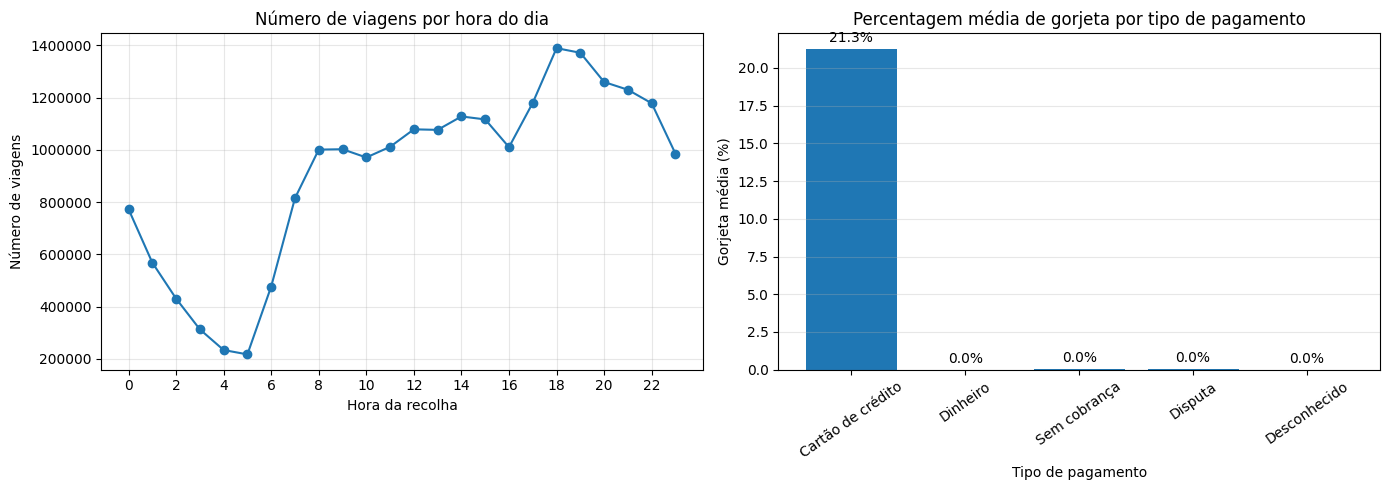

In [48]:
import matplotlib.pyplot as plt

payment_plot = agg_by_payment.sort_values('num_viagens', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Número de viagens por hora do dia
axes[0].plot(
    agg_by_hour['pickup_hour'],
    agg_by_hour['num_viagens'],
    marker='o'
)
axes[0].set_title('Número de viagens por hora do dia')
axes[0].set_xlabel('Hora da recolha')
axes[0].set_ylabel('Número de viagens')
axes[0].set_xticks(range(0, 24, 2))
axes[0].ticklabel_format(style='plain', axis='y')
axes[0].grid(alpha=0.3)

# Gráfico 2: Percentagem média de gorjeta por tipo de pagamento
barras = axes[1].bar(
    payment_plot['payment_label'],
    payment_plot['gorjeta_media_pct']
)

axes[1].bar_label(barras, padding=3, fmt='%.1f%%')

axes[1].set_title('Percentagem média de gorjeta por tipo de pagamento')
axes[1].set_xlabel('Tipo de pagamento')
axes[1].set_ylabel('Gorjeta média (%)')
axes[1].tick_params(axis='x', rotation=35)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
